In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

"""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping"""

'\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import LSTM, Dense\nfrom tensorflow.keras.optimizers import Adam\nfrom tensorflow.keras.regularizers import l2\nfrom tensorflow.keras.layers import Dropout, BatchNormalization\nfrom tensorflow.keras.callbacks import EarlyStopping'

In [23]:
#Configuration
lookback = 3
batch_size = 128
epochs = 300

input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']
#input_features = ['Acc_X', 'Acc_Y', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Head']
target_features = ['delta_Lat', 'delta_Lng']

train_folder = 'data/train'
test_folder = 'data/test'
models_folder = 'models'

In [34]:
# Load and preprocess data from all CSV files in the 'train' folder
def load_data_from_folder(folder_path, lookback):
    sequences = []
    targets = []
    new_input_features = input_features.copy()
    for i in range(1, lookback+1):
        new_input_features.append(f'delta_Lat_t-{i}')
        new_input_features.append(f'delta_Lng_t-{i}')

    for file in os.listdir(folder_path):
        if file.endswith('.csv'):
            # Load the CSV file
            file_path = os.path.join(folder_path, file)
            data = pd.read_csv(file_path, delimiter=";")
            
            # Delete the first row since its deltas are zero
            data = data.drop(0).reset_index(drop=True)

            # Add ass new columns the delta_Lat and delta_Lon from t-1 and t-2
            for i in range(1, lookback+1):
                data[f'delta_Lat_t-{i}'] = data['delta_Lat'].shift(i)
                data[f'delta_Lng_t-{i}'] = data['delta_Lng'].shift(i)

            # Drop the first rows by index
            data = data.drop(range(lookback)).reset_index(drop=True)

            # Normalize the input data (sensor data)
            input_data = data[new_input_features].values
            
            # Target data (deltas)
            target_data = data[target_features].values# * 1000
            
    return np.array(sequences), np.array(targets)

In [35]:
# Load data
X_train, y_train = load_data_from_folder(train_folder, lookback)
X_test, y_test = load_data_from_folder(test_folder, lookback)

In [36]:
# Define the model
model = tf.keras.models.Sequential([
    Input(shape=(784,)),
    Dense(1024, activation='leaky_relu',
    Dropout(0.5),
    BatchNormalization(),
    Dense(1024, activation='leaky_relu',
    Dropout(0.5),
    BatchNormalization(),
    Dense(512, activation='leaky_relu',
    Dropout(0.5),
    BatchNormalization(),
    Dense(256, activation='leaky_relu',
    Dropout(0.5),
    BatchNormalization(),
    Dense(10, activation=None)
])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, start_from_epoch=50)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, callbacks=[early_stopping])  

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

plot_training_histories((history, 'Modelo Final'))

# Save the trained model
model_name = f'dense_model_{sequence_length}seq_{epochs}epochs.keras'
model.save(os.path.join(models_folder, model_name))

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' on line 13 (Temp/ipykernel_14240/4261308691.py, line 17)

In [15]:
def plot_test_data(folder_path, model):
    sequences = []
    targets = []
    
    for file in os.listdir(folder_path):
        # Load the CSV file
        file_path = os.path.join(folder_path, file)
        data = pd.read_csv(file_path, delimiter=";")
        
        if len(data) < sequence_length:
            # Skip files with fewer rows than the sequence length
            continue
        
        # Normalize the input data (sensor data)
        input_data = data[input_features].values
        
        # Target data (deltas)
        target_data = data[target_features].values * 1000
        
        # Create sequences of input data and corresponding target deltas
        for i in range(len(data) - sequence_length):
            sequences.append(input_data[i:i + sequence_length])
            targets.append(target_data[i + sequence_length])
        
        model.layers[0].reset_states()

        y_pred = model.predict(np.array(sequences))
        y_test = np.array(targets)

        # Plot the predicted and true values
        fig, axs = plt.subplots(2, 2, figsize=(25, 20))
        
        # Plot actual vs predicted for delta_Lat
        axs[0, 0].plot(y_test[:, 0], label='Actual delta_Lng', color='blue')
        axs[0, 0].plot(y_pred[:, 0], label='Predicted delta_Lng', color='red')
        axs[0, 0].set_title('Actual vs Predicted delta_Lng')
        axs[0, 0].legend()

        # Plot actual vs predicted for delta_Lng
        axs[0, 1].plot(y_test[:, 1], label='Actual delta_Lat', color='blue')
        axs[0, 1].plot(y_pred[:, 1], label='Predicted delta_Lat', color='red')
        axs[0, 1].set_title('Actual vs Predicted delta_Lat')
        axs[0, 1].legend()

        #Scatter
        # Plot actual vs predicted for deltaY as scatter plot
        axs[1, 0].scatter(range(len(y_test[:, 0])), y_test[:, 0], label='Actual delta_Lng', color='blue')
        axs[1, 0].scatter(range(len(y_pred[:, 0])), y_pred[:, 0], label='Predicted delta_Lng', color='red')
        axs[1, 0].set_title('Actual vs Predicted delta_Lng')
        axs[1, 0].legend()

        axs[1, 1].scatter(range(len(y_test[:, 1])), y_test[:, 1], label='Actual delta_Lat', color='blue')
        axs[1, 1].scatter(range(len(y_pred[:, 1])), y_pred[:, 1], label='Predicted delta_Lat', color='red')
        axs[1, 1].set_title('Actual vs Predicted delta_Lat')
        axs[1, 1].legend()

        # Adjust layout
        fig.suptitle('Test file: ' + file, fontsize=16)
        plt.tight_layout()
        plt.show()


In [16]:
#plot_test_data(test_folder, model)

In [17]:
# Function to calculate real and predicted routes
def calculate_routes(file_path, lookcback, input_features, model, verbose):
    data = pd.read_csv(file_path, delimiter=";")
    
    new_input_features = input_features.copy()
    for i in range(1, lookback+1):
        new_input_features.append(f'delta_Lat_t-{i}')
        new_input_features.append(f'delta_Lng_t-{i}')

    # Get the first point from 'Lat' and 'Lng'
    lat_real = [data.iloc[0]['Lat']]
    lng_real = [data.iloc[0]['Lng']]

    # Initialize real route
    for i in range(1, len(data)):
        # Get the deltas
        delta_lat = data.iloc[i]['delta_Lat']
        delta_lng = data.iloc[i]['delta_Lng']

        # Calculate next point based on the previous one
        lat_real.append(lat_real[-1] + delta_lat)
        lng_real.append(lng_real[-1] + delta_lng)
    
    # Now calculate the predicted route
    lat_pred = [data.iloc[0]['Lat']]
    lng_pred = [data.iloc[0]['Lng']]
    
    # Extract input data
    input_data = data[new_input_features].values
    print("\n\n")
    # Predict deltas and accumulate to form the predicted route
    for i in range(1, len(data)):
        # Prepare sequence for prediction
        if i >= sequence_length:

            X_test = input_data[i-sequence_length:i].reshape(1, lookcback, len(new_input_features))
            delta_lat_pred,delta_lng_pred = model.predict(X_test, verbose=verbose)[0]# / 1000

            print(f"Predicted deltas: {delta_lng_pred}, {delta_lat_pred}")
            print(f"Real deltas: {data.iloc[i]['delta_Lng']}, {data.iloc[i]['delta_Lat']}")
            
            lat_pred.append(lat_pred[-1] + delta_lat_pred)
            lng_pred.append(lng_pred[-1] + delta_lng_pred)

        else:
            # For first few rows, just use the real data
            lat_pred.append(lat_real[i])
            lng_pred.append(lng_real[i])

    
    return lat_real, lng_real, lat_pred, lng_pred

# Function to plot real and predicted routes for each test file
def plot_routes(test_folder, lookcback, input_features, model, verbose):
    test_files = [f for f in os.listdir(test_folder) if f.endswith('.csv')]
    num_files = len(test_files)
    
    fig, axes = plt.subplots(nrows=num_files, ncols=1, figsize=(8, num_files * 6))
    
    if num_files == 1:
        axes = [axes]  #Ensure axes is iterable if there's only one file
    
    for idx, test_file in enumerate(test_files):
        file_path = os.path.join(test_folder, test_file)

        model.layers[0].reset_states()
        
        lat_real, lng_real, lat_pred, lng_pred = calculate_routes(file_path, lookcback, input_features, model, verbose)
        
        # Plot real and predicted points
        axes[idx].plot(lng_real, lat_real, color='blue', label='Real Route', marker='o', markersize=5)
        axes[idx].plot(lng_pred, lat_pred, color='red', label='Predicted Route', marker='o', markersize=5)
        
        axes[idx].set_title(f'Test File: {test_file}')
        axes[idx].set_xlabel('Lng')
        axes[idx].set_ylabel('Lat')
        axes[idx].legend()
    
    # Adjust layout
    plt.tight_layout()
    plt.show()




Predicted deltas: 0.03698872751556337, -0.059604943089652807
Real deltas: 0.002000000000279556, 0.003999999997006398
Predicted deltas: 0.03415065657463856, -0.05963645890005864
Real deltas: -0.0010000000010279564, -0.003999999997006398
Predicted deltas: 0.03733776611625217, -0.059312409575795755
Real deltas: 0.0, -0.007000000003642981
Predicted deltas: 0.03564156577340327, -0.05852657704963349
Real deltas: 0.0030000000013075123, 0.0
Predicted deltas: 0.040317278035217896, -0.05823943138238974
Real deltas: 0.002000000000279556, 0.0
Predicted deltas: 0.0391298090107739, -0.057723365898709744
Real deltas: 0.0029999999995311555, 0.0
Predicted deltas: 0.042082025174750015, -0.05661463728756644
Real deltas: 0.009999999999621425, -0.003999999997006398
Predicted deltas: 0.050208851462230086, -0.05239799793343991
Real deltas: 0.014999999999432134, -0.011999999998124622
Predicted deltas: 0.05783718734164722, -0.047917354095261544
Real deltas: 0.0, -0.007000000003642981
Predicted deltas: 0.059

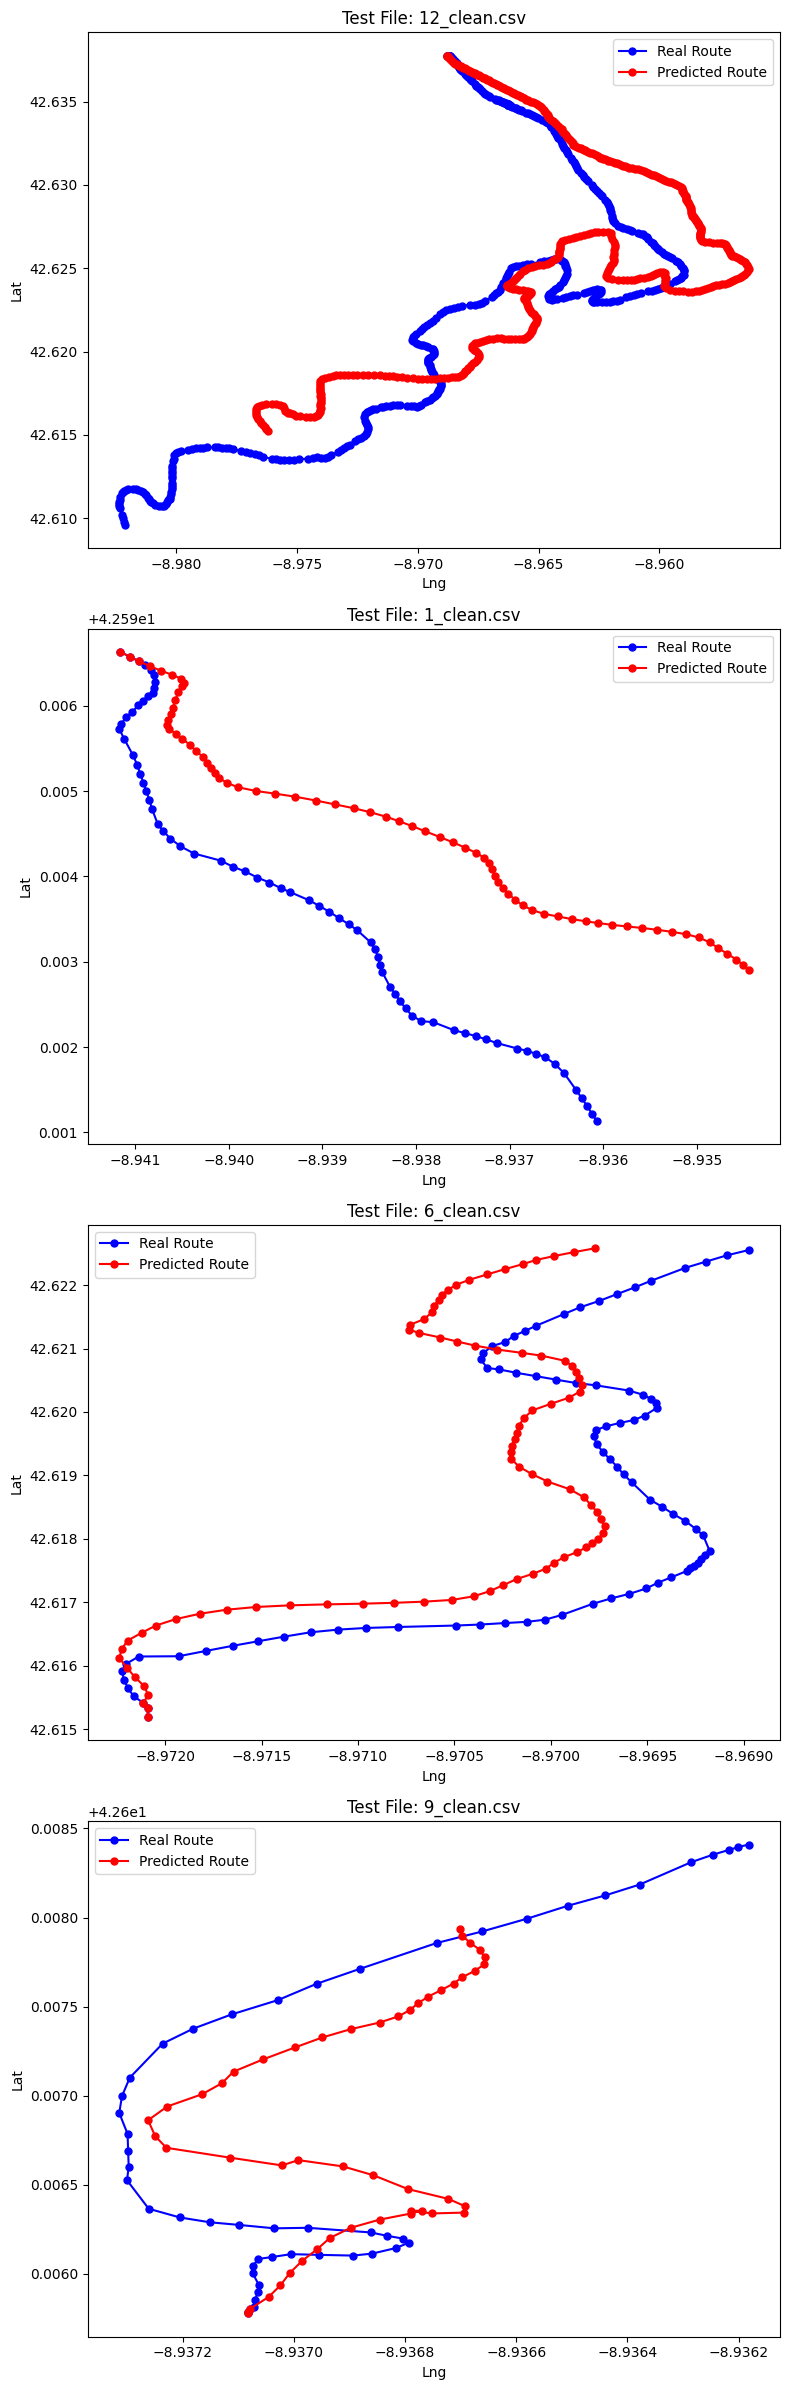

In [18]:
verbose = 0 # Set to 1 to print more information about the training process
plot_routes(test_folder, lookcback, input_features, model, verbose)